In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, f1_score, confusion_matrix, ConfusionMatrixDisplay

In [5]:
cols_needed = ['player_id', 'short_name', 'club_position', 'player_positions', 'fifa_version',
               'pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic']
players = pd.read_csv("male_players (legacy).csv", usecols=cols_needed, low_memory=False)

#keeping only the most recent FIFA version to keep dataset a manageable size
latest_version = players['fifa_version'].max()
players_latest = players[players['fifa_version'] == latest_version].copy()
players_latest ['primary_position'] = players_latest['player_positions'].str.split(',').str[0].str.strip()

#Grouping specific positions into 4 broader categories
position_map = {
    'GK': 'Goalkeeper',
    'CB': 'Defender', 'RB': 'Defender', 'LB': 'Defender', 'RWB': 'Defender', 'LWB': 'Defender',
    'CDM': 'Midfielder', 'CM': 'Midfielder', 'CAM': 'Midfielder', 'RM': 'Midfielder', 'LM': 'Midfielder',
    'ST': 'Forward', 'CF': 'Forward', 'RW': 'Forward', 'LW': 'Forward'
}

players_latest['position_group'] = players_latest['primary_position'].map(position_map)
players_latest = players_latest.dropna(subset=['position_group'])

skill_features = ['pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic']
players_latest[skill_features] = players_latest[skill_features].fillna(players_latest[skill_features].mean())

X1 = players_latest[skill_features]
y1 = players_latest['position_group']

print("FIFA dataset shape after cleaning:", X1.shape)
print(y1.value_counts())
    

FIFA dataset shape after cleaning: (18533, 6)
position_group
Midfielder    6656
Defender      6225
Forward       3586
Goalkeeper    2066
Name: count, dtype: int64


In [9]:
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=42, stratify=y1)

#Model 1: Decision Tree
dt_model_1 = DecisionTreeClassifier(max_depth=6, random_state=42)
dt_model_1.fit(X1_train, y1_train)
dt_predictions_1 = dt_model_1.predict(X1_test)

print("FIFA Players: Decision Tree Results")
print(classification_report(y1_test, dt_predictions_1))

#Model 2: k-Nearest Neighbours
scaler_1 = StandardScaler()
X1_train_scaled = scaler_1.fit_transform(X1_train)
X1_test_scaled = scaler_1.transform(X1_test)

knn_model_1 = KNeighborsClassifier(n_neighbors=7)
knn_model_1.fit(X1_train_scaled, y1_train)
knn_predictions_1 = knn_model_1.predict(X1_test_scaled)

print("FIFA Players: kNN Results")
print(classification_report(y1_test, knn_predictions_1))


FIFA Players: Decision Tree Results
              precision    recall  f1-score   support

    Defender       0.84      0.84      0.84      1245
     Forward       0.74      0.79      0.77       717
  Goalkeeper       1.00      1.00      1.00       413
  Midfielder       0.74      0.70      0.72      1332

    accuracy                           0.80      3707
   macro avg       0.83      0.84      0.83      3707
weighted avg       0.80      0.80      0.80      3707

FIFA Players: kNN Results
              precision    recall  f1-score   support

    Defender       0.87      0.87      0.87      1245
     Forward       0.79      0.76      0.77       717
  Goalkeeper       1.00      1.00      1.00       413
  Midfielder       0.76      0.77      0.77      1332

    accuracy                           0.83      3707
   macro avg       0.85      0.85      0.85      3707
weighted avg       0.83      0.83      0.83      3707



In [17]:
matches = pd.read_csv("results.csv")

def get_outcome(row):
    if row['home_score'] > row['away_score']:
        return 'Home Win'
    elif row['home_score'] < row['away_score']:
        return 'Away Win'
    else:
        return 'Draw'

matches['outcome'] = matches.apply(get_outcome, axis=1)
matches['neutral'] = matches['neutral'].astype(int)

tournament_encoder = LabelEncoder()
matches['tournament_encoded'] = tournament_encoder.fit_transform(matches['tournament'])

#Team win-rate
home_wins = matches[matches['outcome'] == 'Home Win'].groupby('home_team').size()
home_matches_played = matches.groupby('home_team').size()
home_win_rate = (home_wins / home_matches_played).fillna(0)

away_wins = matches[matches['outcome'] == 'Away Win'].groupby('away_team').size()
away_matches_played = matches.groupby('away_team').size()
away_win_rate = (away_wins / away_matches_played).fillna(0)

matches['home_team_win_rate'] = matches['home_team'].map(home_win_rate).fillna(0)
matches['away_team_win_rate'] = matches['away_team'].map(away_win_rate).fillna(0)  

match_features = ['neutral', 'tournament_encoded', 'home_team_win_rate', 'away_team_win_rate']
X2 = matches[match_features]
y2 = matches['outcome']

print("Match dataset shape:", X2.shape)
print(y2.value_counts())
                                                              

    

Match dataset shape: (49520, 4)
outcome
Home Win    24264
Away Win    13996
Draw        11260
Name: count, dtype: int64


In [18]:
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42, stratify=y2)

#Model 1: Decision Tree
dt_model_2 = DecisionTreeClassifier(max_depth=6, random_state=42)
dt_model_2.fit(X2_train, y2_train)
dt_predictions_2 = dt_model_2.predict(X2_test)

print("Match Results: Decision Tree Results")
print(classification_report(y2_test, dt_predictions_2))

#Model 2: k-Nearest Neighbours
scaler_2 = StandardScaler()
X2_train_scaled = scaler_2.fit_transform(X2_train)
X2_test_scaled = scaler_2.transform(X2_test)

knn_model_2 = KNeighborsClassifier(n_neighbors=7)
knn_model_2.fit(X2_train_scaled, y2_train)
knn_predictions_2 = knn_model_2.predict(X2_test_scaled)

print("Match Results: kNN Results")
print(classification_report(y2_test, knn_predictions_2))

Match Results: Decision Tree Results
              precision    recall  f1-score   support

    Away Win       0.52      0.50      0.51      2799
        Draw       0.00      0.00      0.00      2252
    Home Win       0.58      0.87      0.70      4853

    accuracy                           0.57      9904
   macro avg       0.37      0.46      0.40      9904
weighted avg       0.43      0.57      0.49      9904

Match Results: kNN Results
              precision    recall  f1-score   support

    Away Win       0.46      0.51      0.49      2799
        Draw       0.26      0.18      0.21      2252
    Home Win       0.63      0.67      0.65      4853

    accuracy                           0.52      9904
   macro avg       0.45      0.46      0.45      9904
weighted avg       0.50      0.52      0.50      9904



/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


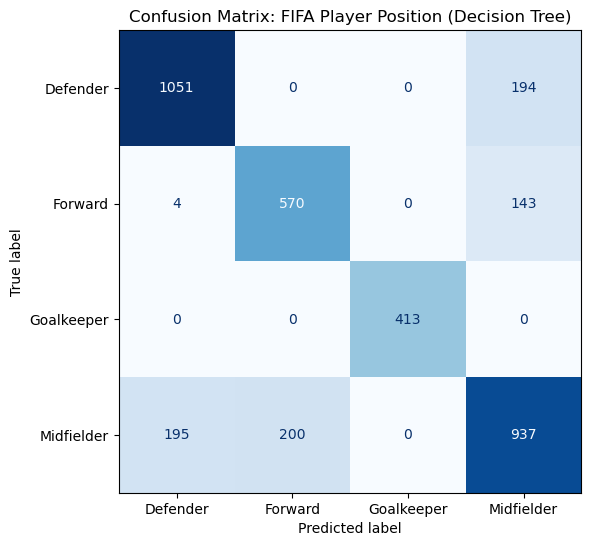

In [21]:
cm = confusion_matrix(y1_test, dt_predictions_1, labels=dt_model_1.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dt_model_1.classes_)

fig1, ax1 = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax1, cmap='Blues', colorbar=False)
ax1.set_title("Confusion Matrix: FIFA Player Position (Decision Tree)")
plt.tight_layout()
plt.savefig("confusion_matrix_fifa_dt.png")
plt.show()

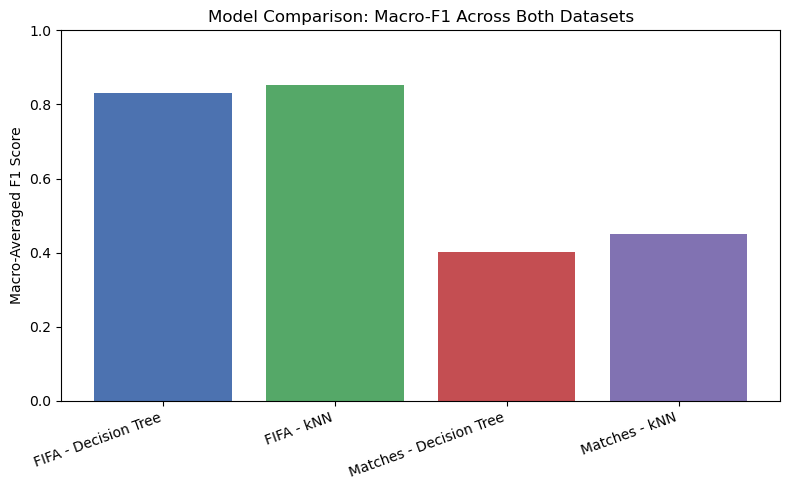

{'FIFA - Decision Tree': 0.8320597417115749, 'FIFA - kNN': 0.8519925955731709, 'Matches - Decision Tree': 0.40321837944052935, 'Matches - kNN': 0.4493188746423458}


In [24]:
macro_f1_scores = {
    "FIFA - Decision Tree": f1_score(y1_test, dt_predictions_1, average='macro'),
    "FIFA - kNN": f1_score(y1_test, knn_predictions_1, average='macro'),
    "Matches - Decision Tree": f1_score(y2_test, dt_predictions_2, average='macro'),
    "Matches - kNN": f1_score(y2_test, knn_predictions_2, average='macro'),
}

fig2, ax2 = plt.subplots(figsize=(8, 5))
ax2.bar(macro_f1_scores.keys(), macro_f1_scores.values(), color=['#4C72B0', '#55A868', '#C44E52', '#8172B2'])
ax2.set_ylabel("Macro-Averaged F1 Score")
ax2.set_title("Model Comparison: Macro-F1 Across Both Datasets")
ax2.set_ylim(0, 1)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig("macro_f1_comparison.png")
plt.show()

print(macro_f1_scores)
    